# A02 Extended Structural Ablations

Main-style appendix exports with one panel per cell and a separate legend strip.

In [6]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NB_ROOT = Path('/workspace/FeaturedMoE/writing/260419_real_final_exp/appendix')
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import appendix_viz_helpers as viz
importlib.reload(viz)

PALETTE = viz.PALETTE
apply_style = viz.apply_style
load_csv = viz.load_csv
load_json = viz.load_json
dataset_label = viz.dataset_label
bar_line_panel = viz.bar_line_panel
single_subfigure_axes = viz.single_subfigure_axes
legend_strip_axes = viz.legend_strip_axes
half_legend_strip_axes = viz.half_legend_strip_axes
add_legend_strip = viz.add_legend_strip
add_metric_legend = viz.add_metric_legend
metric_legend_handles = viz.metric_legend_handles
clean_axes = viz.clean_axes
metric_limits = viz.metric_limits

def compress_display(df, value_cols, group_cols=('dataset',), factor=0.72):
    out = df.copy()
    if out.empty:
        return out
    for _, idx in out.groupby(list(group_cols)).groups.items():
        for col in value_cols:
            vals = pd.to_numeric(out.loc[idx, col], errors='coerce')
            if vals.notna().sum() <= 1:
                continue
            center = float(vals.mean())
            out.loc[idx, col] = center + (vals - center) * factor
    return out

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = NB_ROOT
FIG_DIR = Path('/workspace/FeaturedMoE/writing/ACM_template/figures/appendix')
FIG_DIR.mkdir(parents=True, exist_ok=True)
apply_style()


In [7]:
structural = load_csv('appendix_structural_variants.csv').copy()
structural = structural[structural['base_rank'] == 1].copy()
rep_datasets = ['KuaiRecLargeStrictPosV2_0.2', 'foursquare']
temporal_key_map = {
    'final_three_stage': ('Ours', 'Final 3-stage routing stack'),
    'two_view_remove_mid': ('Global-late', 'Drops the mid scope so the global cue acts late'),
    'two_view_remove_macro': ('Local-first', 'Drops the macro scope and lets local cues decide earlier'),
    'identical_scope': ('Identical scope', 'Forces all stages to read the same temporal view'),
    'scope_swap': ('Scope swap', 'Swaps temporal roles across stages'),
    'extra_attn': ('Extra attn', 'Adds another attention block without introducing a new role'),
}
temporal = structural[structural['setting_key'].isin(temporal_key_map)].copy()
temporal = temporal[temporal['dataset'].isin(rep_datasets)].copy()
temporal['variant_display'] = temporal['setting_key'].map(lambda key: temporal_key_map[key][0])
temporal['experiment_change'] = temporal['setting_key'].map(lambda key: temporal_key_map[key][1])
temporal = temporal[temporal['dataset'].isin(['KuaiRecLargeStrictPosV2_0.2', 'foursquare'])].copy()
temporal_order = ['Ours', 'Global-late', 'Local-first', 'Identical scope', 'Scope swap', 'Extra attn']
temporal_palette = {
    'Ours': PALETTE['route'],
    'Global-late': PALETTE['gold'],
    'Local-first': PALETTE['orange'],
    'Identical scope': PALETTE['blue'],
    'Scope swap': '#8B5E3C',
    'Extra attn': PALETTE['rose'],
}
preview_cols = ['dataset', 'variant_display', 'variant_label', 'experiment_change', 'test_ndcg20', 'test_hit10']
print('A02 temporal variants and what changed:')
print(temporal[preview_cols].drop_duplicates().sort_values(['dataset', 'variant_display']).to_string(index=False))


A02 temporal variants and what changed:
                    dataset variant_display                    variant_label                                           experiment_change  test_ndcg20  test_hit10
KuaiRecLargeStrictPosV2_0.2      Extra attn Extra Attention Without New Role Adds another attention block without introducing a new role       0.3421      0.3550
KuaiRecLargeStrictPosV2_0.2     Global-late             Global-late ordering             Drops the mid scope so the global cue acts late       0.3425      0.3516
KuaiRecLargeStrictPosV2_0.2 Identical scope                  Identical scope            Forces all stages to read the same temporal view       0.3498      0.3583
KuaiRecLargeStrictPosV2_0.2     Local-first             Local-first ordering    Drops the macro scope and lets local cues decide earlier       0.3442      0.3550
KuaiRecLargeStrictPosV2_0.2            Ours                    Final 3-stage                                 Final 3-stage routing stack       0.3538 

KuaiRec | temporal structural variants
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a02_structural_temporal_a.pdf


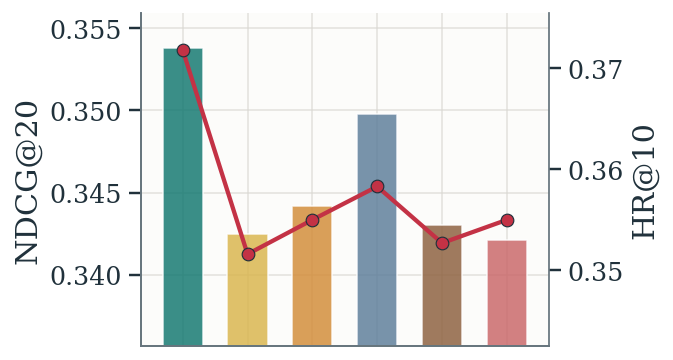

In [8]:
sub = temporal[temporal['dataset'] == 'KuaiRecLargeStrictPosV2_0.2'].copy()
print('KuaiRec | temporal structural variants')
fig, ax = single_subfigure_axes()
bar_line_panel(sub, 'variant_display', 'test_ndcg20', 'test_hit10', ax,
               order=temporal_order, bar_label='NDCG@20', line_label='HR@10',
               xrotation=0, palette_override=temporal_palette, show_xticklabels=False)
fig.savefig(FIG_DIR / 'a02_structural_temporal_a.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a02_structural_temporal_a.pdf')
plt.show()

Foursquare | temporal structural variants
[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a02_structural_temporal_b.pdf


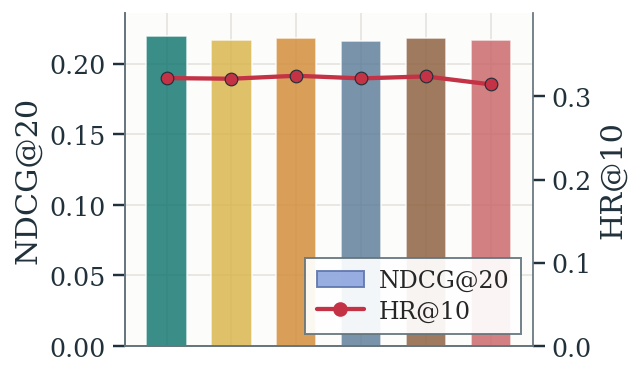

In [9]:
sub = temporal[temporal['dataset'] == 'foursquare'].copy()
print('Foursquare | temporal structural variants')
fig, ax = single_subfigure_axes()
bar_line_panel(sub, 'variant_display', 'test_ndcg20', 'test_hit10', ax,
               order=temporal_order, bar_label='NDCG@20', line_label='HR@10',
               xrotation=0, palette_override=temporal_palette, show_xticklabels=False,
               add_metric_legend_box=True, metric_legend_loc='lower right',
               bar_limits=(0.0, max(sub['test_ndcg20'].max() + 0.016, 0.08)),
               line_limits=(0.0, max(sub['test_hit10'].max() + 0.075, 0.24)))
fig.savefig(FIG_DIR / 'a02_structural_temporal_b.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a02_structural_temporal_b.pdf')
plt.show()

[saved] /workspace/FeaturedMoE/writing/ACM_template/figures/appendix/a02_structural_temporal_legend.pdf


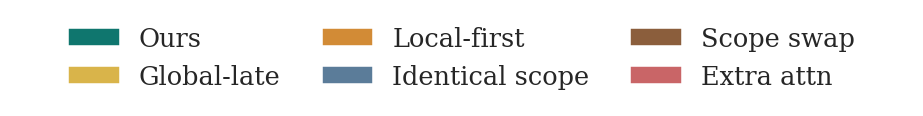

In [10]:
fig, ax = legend_strip_axes()
add_legend_strip(ax, temporal_order, [temporal_palette[k] for k in temporal_order], ncol=3)
fig.savefig(FIG_DIR / 'a02_structural_temporal_legend.pdf', bbox_inches='tight')
print('[saved]', FIG_DIR / 'a02_structural_temporal_legend.pdf')
plt.show()